## Test on elastic asynchronous gd

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [42]:
# ── Synchronous EASGD ─────────────────────────────────────────────────────────
def easgd(grad, num_workers=4, eta=0.01, rho=0.1, num_epochs=300, dim=2):
    alpha = eta * rho
    beta  = num_workers * alpha

    x_center = np.array([-0.5, 1.5])   # classic hard start for Rosenbrock
    workers  = [x_center.copy() for _ in range(num_workers)]

    master_trajectory  = [x_center.copy()]
    worker_trajectories = [[w.copy()] for w in workers]  # one list per worker

    for _ in range(num_epochs):
        for i in range(num_workers):
            g = grad(workers[i])
            workers[i] = (workers[i]
                          - eta   * g
                          - alpha * (workers[i] - x_center))
            worker_trajectories[i].append(workers[i].copy())  # record after each step

        worker_mean = np.mean(workers, axis=0)
        x_center    = (1 - beta) * x_center + beta * worker_mean
        master_trajectory.append(x_center.copy())

    return x_center, master_trajectory, worker_trajectories

# ── Plain Gradient Descent ────────────────────────────────────────────────────
def plain_gd(grad, eta=0.01, num_epochs=300):
    x = np.array([-0.5, 1.5])
    trajectory = [x.copy()]
    for _ in range(num_epochs):
        x = x - eta * grad(x)
        trajectory.append(x.copy())
    return x, trajectory

In [37]:
# ── Loss & gradient ───────────────────────────────────────────────────────────
def sphere_fn(theta):
    x, y = theta
    return x**2 + y**2

def sphere_gd(theta):
    x, y = theta
    return np.array([2*x, 2*y])   # FIX: must return a vector, not a scalar


# ── Rosenbrock  f(x,y) = (1-x)² + 100(y-x²)²  —  global min = 0 at (1, 1) ──
def rosenbrock_fn(theta):
    x, y = theta
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_gd(theta):
    x, y = theta
    dfdx = -2 * (1 - x) - 400 * x * (y - x**2)
    dfdy =  200 * (y - x**2)
    g = np.array([dfdx, dfdy])
    return np.clip(g, -10.0, 10.0)   # clip to prevent gradient explosion


def rastrigin_fn(theta):
    A = 2*10
    return A + sum([(x**2 - A * np.cos(2 * math.pi * x)) for x in theta])

def rastrigin_gd(theta):
    A = 2*10
    return np.array([2*x - 2*math.pi*A * np.sin(2 * math.pi * x) for x in theta])



In [21]:
# ── Plot ──────────────────────────────────────────────────────────────────────
def draw_path(ax, trajectory, color, label):
    """Draw a trajectory with directional arrows on ax."""
    pts = np.array(trajectory)          # shape (N, 2)
    tx, ty = pts[:, 0], pts[:, 1]

    ax.plot(tx, ty, color=color, linewidth=1.5, alpha=0.8, label=label)
    ax.scatter(tx[0],  ty[0],  s=100, color="lime",  zorder=5)
    ax.scatter(tx[-1], ty[-1], s=100, color=color,   zorder=5, marker="*")

    step = max(1, len(tx) // 15)
    for i in range(0, len(tx) - step, step):
        ax.annotate("",
            xy=(tx[i+step], ty[i+step]),
            xytext=(tx[i], ty[i]),
            arrowprops=dict(arrowstyle="->", color=color, lw=1.0),
        )
def plot_trajectories(fn, master_trajectory, gd_trajectory,minimum, r=2.0):
    xs = np.linspace(-r, r, 400)
    ys = np.linspace(-r, r * 1.5, 400)   # taller range to capture the valley
    Z  = np.array([[fn(np.array([xi, yj])) for xi in xs] for yj in ys])

    fig, ax = plt.subplots(figsize=(8, 7))
    cp = ax.contourf(xs, ys, np.log1p(Z), levels=60, cmap="viridis")  # log scale so the valley is visible
    plt.colorbar(cp, ax=ax, label="log(1 + Loss)")

    draw_path(ax, gd_trajectory,     color="tomato", label="Plain GD")
    draw_path(ax, master_trajectory, color="white",  label="EASGD master")

    ax.scatter([], [], s=100, color="lime", label="Start (both)")
    ax.scatter(minimum[0], minimum[1], s=200, color="yellow", marker="*", zorder=6, label="Global min")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title("Plain GD vs EASGD Master — Rosenbrock function")
    ax.legend()
    plt.tight_layout()
    plt.show()

EASGD final loss   : 22.370551
Plain GD final loss: 0.074176


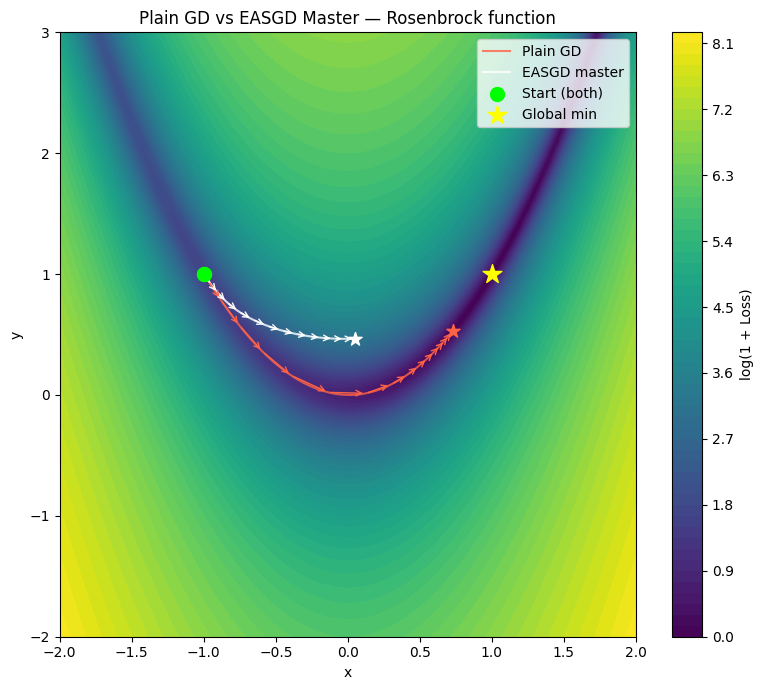

In [30]:
_, master_trajectory, _ = easgd(rosenbrock_gd, num_workers=8, eta=0.001, rho=0.1, num_epochs=2000)
_, gd_trajectory        = plain_gd(rosenbrock_gd, eta=0.001, num_epochs=2000)

print(f"EASGD final loss   : {rosenbrock_fn(master_trajectory[-1]):.6f}")
print(f"Plain GD final loss: {rosenbrock_fn(gd_trajectory[-1]):.6f}")

plot_trajectories(rosenbrock_fn, master_trajectory, gd_trajectory,minimum=[1,1], r=2.0)

EASGD final loss   : 1.126289
Plain GD final loss: 0.000666


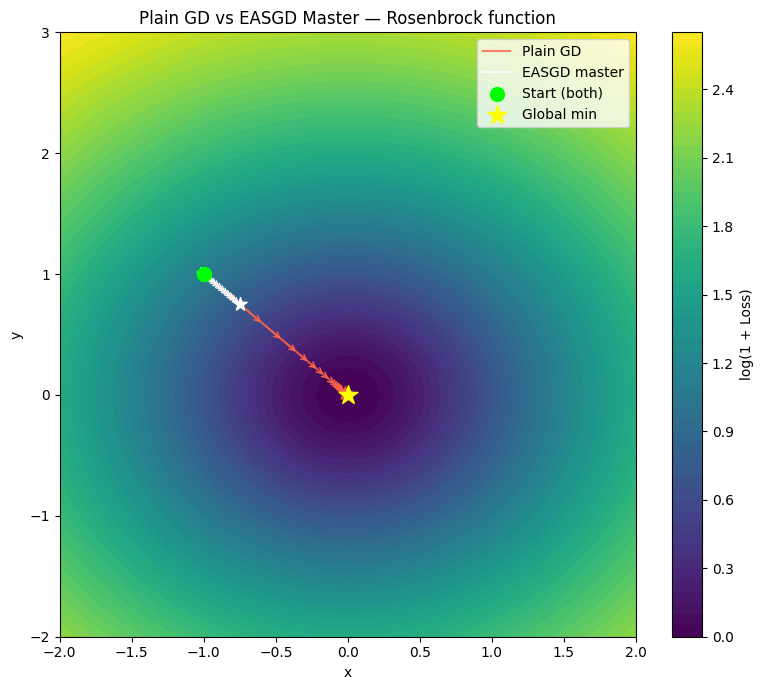

In [18]:
_, master_trajectory, _ = easgd(sphere_gd, num_workers=2, eta=0.001, rho=0.1, num_epochs=2000)
_, gd_trajectory        = plain_gd(sphere_gd, eta=0.001, num_epochs=2000)

print(f"EASGD final loss   : {sphere_fn(master_trajectory[-1]):.6f}")
print(f"Plain GD final loss: {sphere_fn(gd_trajectory[-1]):.6f}")

plot_trajectories(sphere_fn, master_trajectory, gd_trajectory,minimum=[0,0], r=2.0)

EASGD final loss   : 62.498741
Plain GD final loss: 62.481080


C:\Users\Léa\AppData\Local\Temp\ipykernel_3168\4161604398.py:24: RuntimeWarning: invalid value encountered in log1p
  cp = ax.contourf(xs, ys, np.log1p(Z), levels=60, cmap="viridis")  # log scale so the valley is visible


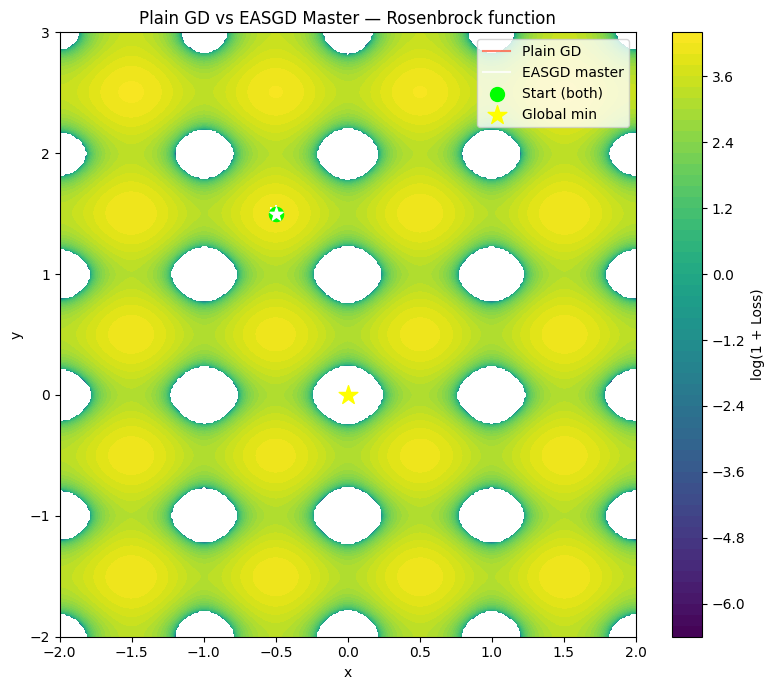

In [48]:
_, master_trajectory, _ = easgd(rastrigin_gd, num_workers=2, eta=0.001, rho=0.1, num_epochs=500)
_, gd_trajectory        = plain_gd(rastrigin_gd, eta=0.001, num_epochs=500)

print(f"EASGD final loss   : {rastrigin_fn(master_trajectory[-1]):.6f}")
print(f"Plain GD final loss: {rastrigin_fn(gd_trajectory[-1]):.6f}")

plot_trajectories(rastrigin_fn, master_trajectory, gd_trajectory,minimum=[0,0], r=2.0)